In [1]:
import sys
sys.path.append("../")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from py_code import add_variables
from py_code import get_variables
from py_code import initialize_df
import matplotlib
matplotlib.rc('text', usetex=True)
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath,amssymb}"
plt.style.use('plots.mplstyle')
from matplotlib.patches import Patch, Rectangle
from pathlib import Path

In [2]:
df_path = "../dfs_feats/mPMT_HAWCSim_array/train/sm_bkg/100300TeV_030deg_4FF_180R175h_Black/NoneMHz_ADC_13petrain_13petest_500ns/df_mPMT_NoneMHz_ADC_13bkg13smu_pe.parquet"
pe_min = 13
min_dist = 0
max_dist = 700

df = pd.read_parquet(df_path)
df = df[df["total_pe"] >= pe_min]
df = df[df["T_C"] >= min_dist]
df = df[df["T_C"] <= max_dist]

df_mu   = df[df["IsThereMuon"] == 1]
df_nomu = df[df["IsThereMuon"] == 0]

print("All done! :))")

All done! :))


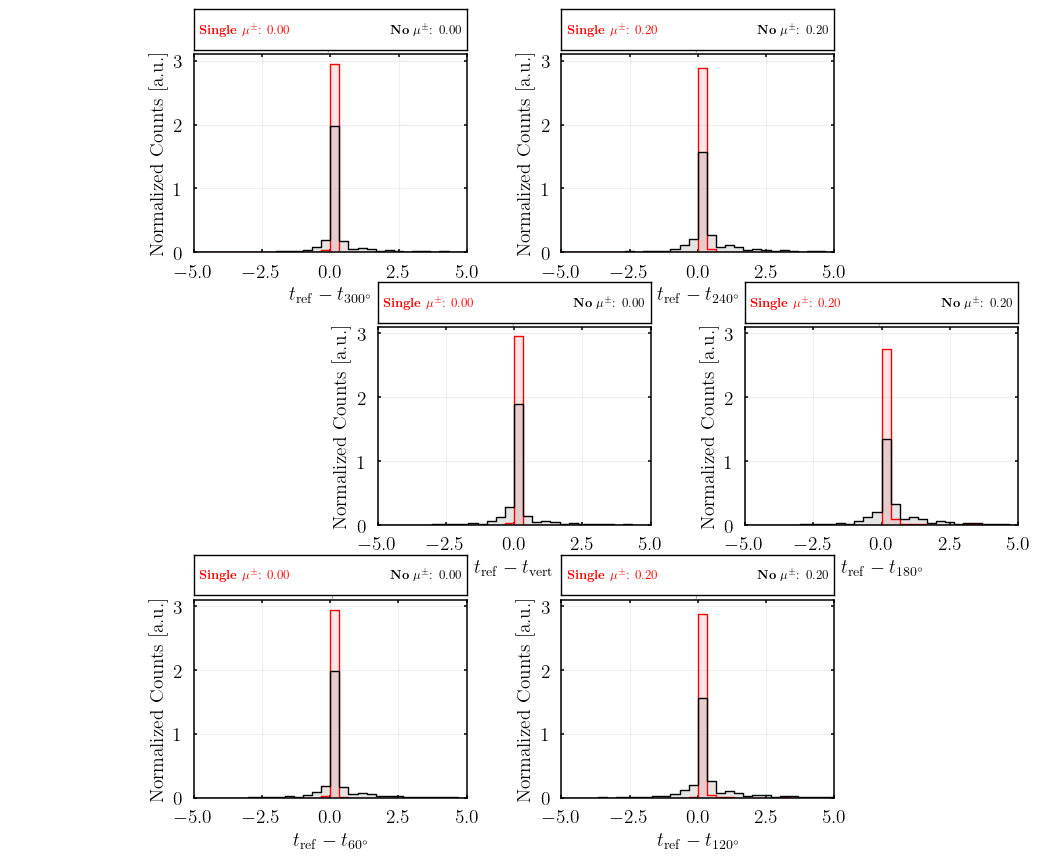

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
import matplotlib.transforms as mtransforms


class OffsetHandler(HandlerBase):
    def __init__(self, x_offset=0, y_offset=0, **kwargs):
        self.x_offset = x_offset
        self.y_offset = y_offset
        super().__init__(**kwargs)

    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans
    ):
        patch = Rectangle(
            (0, 0),
            width,
            height,
            facecolor=orig_handle.get_facecolor(),
            edgecolor=orig_handle.get_edgecolor(),
            linewidth=orig_handle.get_linewidth()
        )

        offset_transform = (
            trans
            + mtransforms.Affine2D().translate(
                self.x_offset,
                self.y_offset
            )
        )

        patch.set_transform(offset_transform)
        return [patch]


tref_data_mu = {
    "0": df_mu["t_ref0"],
    "60": df_mu["t_ref60"],
    "120": df_mu["t_ref120"],
    "180": df_mu["t_ref180"],
    "240": df_mu["t_ref240"],
    "300": df_mu["t_ref300"],
}

tref_data_nomu = {
    "0": df_nomu["t_ref0"],
    "60": df_nomu["t_ref60"],
    "120": df_nomu["t_ref120"],
    "180": df_nomu["t_ref180"],
    "240": df_nomu["t_ref240"],
    "300": df_nomu["t_ref300"],
}


fig = plt.figure(figsize=(10.5, 9))

w, h = 0.26, 0.22
cx, cy = 0.43, 0.50
r = 0.35


# Left position is intentionally empty.
#
# Counterclockwise from the empty left position:
# 60 -> 120 -> 180 -> 240 -> 300
pos = {
    "0": [
        cx - w/2,
        cy - h/2,
        w,
        h
    ],

    "ref": [                     # <- empty placeholder
        cx - r - w/2,
        cy - h/2,
        w,
        h
    ],

    "60": [
        cx + r*np.cos(np.deg2rad(240)) - w/2,
        cy + r*np.sin(np.deg2rad(240)) - h/2,
        w,
        h
    ],

    "120": [
        cx + r*np.cos(np.deg2rad(300)) - w/2,
        cy + r*np.sin(np.deg2rad(300)) - h/2,
        w,
        h
    ],

    "180": [
        cx + r - w/2,
        cy - h/2,
        w,
        h
    ],

    "240": [
        cx + r*np.cos(np.deg2rad(60)) - w/2,
        cy + r*np.sin(np.deg2rad(60)) - h/2,
        w,
        h
    ],

    "300": [
        cx + r*np.cos(np.deg2rad(120)) - w/2,
        cy + r*np.sin(np.deg2rad(120)) - h/2,
        w,
        h
    ],
}


axes_keys = ["ref", "0", "60", "120", "180", "240", "300"]

axes_list = {}

for key in axes_keys:

    a = fig.add_axes(pos[key])
    axes_list[key] = a

    if key == "ref":
        a.set_axis_off()
        continue

    tref_mu = tref_data_mu[key].dropna()
    tref_nomu = tref_data_nomu[key].dropna()

    counts_mu, bin_edges = np.histogram(
        tref_mu,
        bins=60,
        range=(-10, 10),
        density=True
    )

    counts_nomu, _ = np.histogram(
        tref_nomu,
        bins=60,
        range=(-10, 10),
        density=True
    )

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    step_x = np.r_[
        bin_edges[0],
        np.repeat(bin_edges, 2)[1:-1],
        bin_edges[-1]
    ]

    step_y_mu = np.r_[0, np.repeat(counts_mu, 2), 0]
    step_y_nomu = np.r_[0, np.repeat(counts_nomu, 2), 0]

    a.step(step_x, step_y_mu, color="red", linewidth=1)
    a.step(step_x, step_y_nomu, color="black", linewidth=1)

    a.bar(
        bin_centers,
        counts_mu,
        width=bin_width,
        color="red",
        alpha=0.1,
        align="center"
    )

    a.bar(
        bin_centers,
        counts_nomu,
        width=bin_width,
        color="black",
        alpha=0.1,
        align="center"
    )

    a.set_xlim(-5, 5)
    a.set_ylim(0, 3.1)

    label = "vert" if key == "0" else f"{key}^\\circ"

    a.set_xlabel(
        rf"$t_{{\mathrm{{ref}}}} - t_{{\mathrm{{{label}}}}}$",
        fontsize=14
    )

    a.set_ylabel(
        r"Normalized Counts [a.u.]",
        fontsize=14
    )

    a.tick_params(
        axis="both",
        which="both",
        labelsize=14,
        length=2.5
    )

    a.minorticks_off()
    a.grid(True, alpha=0.2)

    if key == "0":
        a.set_title(
            r"$t_{\mathrm{ref},\mathrm{vert}}$",
            fontsize=16
        )
    else:
        a.set_title(
            rf"$t_{{\mathrm{{ref}},{key}^\circ}}$",
            fontsize=16
        )

    # Do not call this variable "pos":
    # that name is already used by the position dictionary.
    ax_pos = a.get_position()

    legend_ax = fig.add_axes([
        ax_pos.x0,
        ax_pos.y1 + 0.005,
        ax_pos.width,
        0.045
    ])

    legend_ax.set_xticks([])
    legend_ax.set_yticks([])
    legend_ax.set_facecolor("white")

    for spine in legend_ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)

    legend_ax.text(
        0.02,
        0.5,
        rf"$\bf{{Single}}\ \mu^{{\pm}}$: {np.median(tref_mu):.2f}",
        color="red",
        va="center",
        ha="left",
        fontsize=9
    )

    legend_ax.text(
        0.98,
        0.5,
        rf"$\bf{{No}}\ \mu^{{\pm}}$: {np.median(tref_nomu):.2f}",
        color="black",
        va="center",
        ha="right",
        fontsize=9
    )

plt.show()